# Week 6-1 · Tutorial — Doubt-Solving on Python (after PBQ)
**Instructor: Mahavir.** A practical follow-up to PBQ-01 that clears the *mechanics* beginners trip over:
how to import libraries, what a working directory is, **which bracket goes where**, attribute-vs-method,
and magic commands. This notebook makes every one of those answers runnable.

**The questions this tutorial answers:**
1. What is a **library**? built-in vs third-party
2. **Working directory** — `os.getcwd`, `os.chdir`, `dir()`
3. The **five ways to import** (and why `import *` is discouraged)
4. **Namespace overriding** — `math.sin` vs `cmath.sin`
5. **Attribute vs method** — why `df.shape` has *no* parentheses but `df.describe()` does
6. **Which bracket?** round `( )` · square `[ ]` · curly `{ }`
7. **Magic commands** — `%who`, `%whos`, `%pwd`, `%timeit`, `%history`

> One housekeeping note: the live session used `yfinance` to pull data. It isn't installed here, so we use
> the **TCS.NS.csv** file (from PBQ-01) and Python's standard library instead — the *concepts* are identical.


In [1]:
import os, math, cmath
import numpy as np
import pandas as pd
print("os, math, cmath = built-in (standard library, no install needed)")
print("numpy, pandas   = third-party (installed from a server, then imported)")


os, math, cmath = built-in (standard library, no install needed)
numpy, pandas   = third-party (installed from a server, then imported)


## Part 1 — What is a library? Built-in vs third-party

A **library** is pre-assembled code for a specific job — like a labelled toolbox. You wouldn't groom with a
hammer or fix a shelf with a razor; likewise each library has its purpose:

| library | full name | job |
|---|---|---|
| `pandas` | **pan**el **da**ta | read / manipulate / analyse tabular data |
| `numpy` | **num**erical **py**thon | fast numeric & matrix maths |
| `matplotlib` | math plotting library | visualise data |

There are ~137,000 libraries on PyPI, but a quant uses maybe 15–20 regularly. **Built-in** libraries
(`os`, `urllib`, `math`) ship with Python — just `import`. **Third-party** ones (`numpy`, `pandas`,
`sklearn`) must be *installed once* from a server, then *imported every session*.

In [2]:
# install = download to disk ONCE; import = load into memory EACH session
# (analogy: buy the toolbox once; fetch it from the cupboard each time you use it)
print("numpy is already installed -> we can import it. version:", np.__version__)
print("math is built-in -> sqrt(144) =", math.sqrt(144))


numpy is already installed -> we can import it. version: 2.2.6
math is built-in -> sqrt(144) = 12.0


## Part 2 — The working directory (`os`)

`pd.read_csv("file.csv")` only finds the file if it sits in your **current working directory** (CWD). The
`os` library lets you check and change it — the fix for the classic *FileNotFoundError*.

In [3]:
print("current working directory:")
print("  ", os.getcwd())
print("\nfiles here:", [f for f in os.listdir() if f.endswith('.csv')])
# os.chdir(path) would move the CWD; we stay put because TCS.NS.csv is already here
df = pd.read_csv("TCS.NS.csv")
print("\nread TCS.NS.csv ->", df.shape, "rows x cols")


current working directory:
   C:\Users\hsaeed\Downloads\EPAT-Git\_validation_work\week6_1_pbq01_tutorial\notebook_exec_20260702_092837

files here: ['TCS.NS.csv', 'week6_bracket_reference.csv', 'week6_import_reference.csv', 'week6_learning_tools_reference.csv', 'week6_magic_reference.csv', 'week6_tcs_visualization_stats.csv']

read TCS.NS.csv -> (2460, 7) rows x cols


`dir(library)` lists everything inside a library — handy when you forget a method name.

In [4]:
print("first 8 callables in math:", [d for d in dir(math) if not d.startswith('_')][:8])


first 8 callables in math: ['acos', 'acosh', 'asin', 'asinh', 'atan', 'atan2', 'atanh', 'cbrt']


## Part 3 — The five ways to import

The order matters: `from B import A` works (Python finds library **B**, then pulls **A** out); `import A
from B` is a syntax error. The library is what gets stored, so it comes first.

In [5]:
# 1) plain                import math
# 2) aliased (preferred)   import numpy as np
# 3) star (discouraged)    from math import *      <- floods the namespace
# 4) specific function     from math import sqrt
# 5) function + alias       from math import sqrt as root
from math import sqrt as root
print("alias example: root(81) =", root(81))
print("aliasing saves typing & keeps the namespace traceable")


alias example: root(81) = 9.0
aliasing saves typing & keeps the namespace traceable


## Part 4 — Namespace overriding: `math.sin` vs `cmath.sin`

The danger of `from ... import *`: if two libraries define the same name, **the later import wins** and you
lose track of where a function came from. This is why `import *` is discouraged in real projects.

In [6]:
from math import sin        # real-valued sin
from cmath import sin       # complex-valued sin  -> OVERRIDES the previous one
print("sin(1.0) now =", sin(1.0))          # complex result: the cmath version won
print("type:", type(sin(1.0)).__name__, " <- cmath imported later, so it overrode math.sin")
# the fix: keep the namespace explicit
print("explicit -> math.sin(1.0) =", round(math.sin(1.0), 6))


sin(1.0) now = (0.8414709848078965+0j)
type: complex  <- cmath imported later, so it overrode math.sin
explicit -> math.sin(1.0) = 0.841471


## Part 5 — Attribute vs method: the `shape` / `describe()` confusion

The tutorial's headline doubt. `df.shape` is an **attribute** (a stored value) → **no parentheses**.
`df.describe()` is a **method** (an action you call) → **needs parentheses**. Calling an attribute like a
method (`df.shape()`) raises *'tuple' object is not callable*.

In [7]:
print("df.shape   ->", df.shape, "  | type:", type(df.shape).__name__, "(an attribute -> no parens)")
desc = df["Close"].describe()
print("\ndf['Close'].describe() (a method -> needs parens):")
print(desc.round(2).to_string())
print("\ntype of the .describe attribute:", type(df.describe).__name__, "(method -> callable)")


df.shape   -> (2460, 7)   | type: tuple (an attribute -> no parens)

df['Close'].describe() (a method -> needs parens):
count    2460.00
mean     1170.19
std       523.20
min       349.77
25%       645.58
50%      1198.76
75%      1334.99
max      2277.95

type of the .describe attribute: method (method -> callable)


**The rule of thumb:** `library.method(arguments)` — parentheses hold *arguments*. If there are no
arguments to pass and you're just reading a stored fact, it's an attribute and the parentheses vanish.

## Part 6 — Which bracket goes where?

| bracket | used for |
|---|---|
| round `( )` | call functions/methods, pass arguments, define **tuples**, group arithmetic |
| square `[ ]` | define **lists**, index & slice |
| curly `{ }` | define **sets** and **dictionaries**, hold variables inside **f-strings** |

In [8]:
# round () -> define a function and a tuple
def add_and_mult(a, b, c):          # () holds the parameters
    return (a + b + c, a * b * c)   # () makes a tuple
print("add_and_mult(2,5,9) =", add_and_mult(2, 5, 9))

# square [] -> list, indexing, slicing
lst = [1, 5.9, True, "EPAT", 4-8j]
print("\nlist[0]   =", lst[0])
print("list[0:3] =", lst[0:3], " (0,1,2 — index 3 excluded)")
lst.append(47); print("after append:", lst)      # lists are mutable

tup = (1, 5.9, True)                # tuple is immutable -> no .append
print("tuple has append?", hasattr(tup, "append"))


add_and_mult(2,5,9) = (16, 90)

list[0]   = 1
list[0:3] = [1, 5.9, True]  (0,1,2 — index 3 excluded)
after append: [1, 5.9, True, 'EPAT', (4-8j), 47]
tuple has append? False


In [9]:
# curly {} -> set (unique, unordered), dict (key:value), and f-strings
unique = {1, 1, 2, 3, 3}            # duplicates collapse
prices = {"MSFT": 300, "TSLA": 248}
print("set drops duplicates:", unique)
print("dict lookup MSFT:", prices["MSFT"])

course, quality, faculty = "EPAT", "high", "amazing"
print(f"\nI enrolled in {course}; the quality is {quality} and the faculty is {faculty}.")  # f-string uses {}


set drops duplicates: {1, 2, 3}
dict lookup MSFT: 300

I enrolled in EPAT; the quality is high and the faculty is amazing.


### Commas and underscores
- **comma** `,` separates items/arguments (lists, tuples, function calls) — same as English.
- **underscore** `_` makes long variable names readable: `my_first_python_variable`.

## Part 7 — Magic commands

Magic commands start with `%` and give Jupyter shortcuts. `%who`/`%whos` list your variables, `%pwd` shows
the directory, `%history` recalls past commands, and **`%timeit`** benchmarks code — its headline lesson is
that work often **does not scale linearly**.

In [10]:
stock_price = 300
%who                       # bare list of variable names


lst	 


In [11]:
# %timeit runs code many times and reports mean +/- std dev
print("sum first 10 numbers:")
%timeit sum(range(10))
print("sum first 20 numbers (NOT simply double the time -> non-linear):")
%timeit sum(range(20))
print("sum first 1000 numbers:")
%timeit sum(range(1000))


sum first 10 numbers:


205 ns ± 2.02 ns per loop (mean ± std. dev. of 7 runs, 10,000,000 loops each)
sum first 20 numbers (NOT simply double the time -> non-linear):


256 ns ± 14.2 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
sum first 1000 numbers:


13.3 µs ± 297 ns per loop (mean ± std. dev. of 7 runs, 100,000 loops each)


The ratio of timings between *first 10* and *first 20* — rather than the raw numbers — hints at the
code's **time complexity**. Comparing approaches this way is how you write scalable code.

## Summary — the mechanics, cleared up
- A **library** is a labelled toolbox; **built-in** (`os`, `math`) needs no install, **third-party** (`numpy`, `pandas`) is installed once, imported each session.
- **Working directory:** `os.getcwd()` to check, `os.chdir()` to move; `read_csv` only sees files in the CWD. `dir(lib)` lists its contents.
- **Five imports:** plain, `as` alias (preferred), `*` (discouraged), `from import`, `from import as`. The library name always comes first.
- **Namespace overriding:** the later `import *` wins — keep names explicit (`math.sin`) so code stays traceable.
- **Attribute vs method:** `df.shape` (stored value, no `()`) vs `df.describe()` (action, needs `()`).
- **Brackets:** round `()` = call/tuple/args, square `[]` = list/index/slice, curly `{}` = set/dict/f-string.
- **Magic commands:** `%who`/`%whos`, `%pwd`, `%history`, and `%timeit` (work rarely scales linearly).

> Next tutorial: PBQ-02 (Python Basics for Quants).


---

# Validated additive resource section

The following cells were appended during validation to cover source-session gaps while preserving every original cell above.

# Week 6-1 Resource Addendum - Python Doubt Solving

This additive practice notebook fills the source-session gaps that are easy to miss in a compact study sheet: `urllib`, documentation inspection, AI verification, IDE choices, Git, and a TCS visualization check. It uses only local files, so it can run offline.

In [12]:
from pathlib import Path
import inspect
import math
import cmath
import os
import timeit
from urllib import request

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

DATA_FILE = Path("TCS.NS.csv")
print("setup complete")
print("cwd:", Path.cwd())
print("TCS file exists:", DATA_FILE.exists())

setup complete
cwd: C:\Users\hsaeed\Downloads\EPAT-Git\_validation_work\week6_1_pbq01_tutorial\notebook_exec_20260702_092837
TCS file exists: True


## 1. Import order, CWD, and `urllib`

The session reinforced that the library/package name comes first in `from B import A`. The offline example below uses `urllib.request.urlopen` against a local `file://` URL, which demonstrates the same object pattern without making a network call.

In [13]:
file_url = DATA_FILE.resolve().as_uri()
with request.urlopen(file_url) as response:
    first_line = response.readline().decode("utf-8").strip()

print("from urllib import request -> request.urlopen(...)")
print("URL scheme:", file_url.split(":", 1)[0])
print("CSV header:", first_line)

from urllib import request -> request.urlopen(...)
URL scheme: file
CSV header: Date,High,Low,Open,Close,Volume,Adj Close


## 2. Inspect before guessing

`dir(object)` lists names. In Jupyter, `object?` shows help/signature and `object??` can show source when it is available. Programmatically, `inspect.signature` and docstrings give the same habit: check what a function accepts before using it.

In [14]:
public_math_names = [name for name in dir(math) if not name.startswith("_")][:10]
read_csv_signature = inspect.signature(pd.read_csv)
pct_change_doc = pd.Series.pct_change.__doc__.strip().splitlines()[0]

print("first 10 public math names:", public_math_names)
print("pd.read_csv signature starts:", str(read_csv_signature)[:95] + "...")
print("pct_change doc first line:", pct_change_doc)

first 10 public math names: ['acos', 'acosh', 'asin', 'asinh', 'atan', 'atan2', 'atanh', 'cbrt', 'ceil', 'comb']
pd.read_csv signature starts: (filepath_or_buffer: 'FilePath | ReadCsvBuffer[bytes] | ReadCsvBuffer[str]', *, sep: 'str | Non...
pct_change doc first line: Fractional change between the current and a prior element.


## 3. Namespace collisions and bracket checks

Star imports and repeated `from ... import name` statements can silently replace a name. The clear pattern is module-qualified calls (`math.sin`, `cmath.sin`) and explicit bracket use.

In [15]:
print("math.sin(1.0):", math.sin(1.0))
print("cmath.sin(1.0):", cmath.sin(1.0))

prices = [100, 102, 101, 105]
ticker_to_price = {"TCS": prices[-1], "NIFTY": 24000}
unique_prices = set(prices)

print("slice prices[1:3] (stop excluded):", prices[1:3])
print("enumerate pairs:", list(enumerate(prices[:3], start=1)))
print("dict lookup ticker_to_price['TCS']:", ticker_to_price["TCS"])
print("set keeps unique values:", sorted(unique_prices))

math.sin(1.0): 0.8414709848078965
cmath.sin(1.0): (0.8414709848078965+0j)
slice prices[1:3] (stop excluded): [102, 101]
enumerate pairs: [(1, 100), (2, 102), (3, 101)]
dict lookup ticker_to_price['TCS']: 105
set keeps unique values: [100, 101, 102, 105]


## 4. Local TCS visualization practice

The source tutorial included market-data visualization. This cell parses the local TCS file, computes daily returns, shows a compact audit table, and plots price plus return distribution.

,metric,value
0,rows,2460
1,start,2010-04-26
2,end,2020-04-20
3,mean daily return,0.000874
4,annualized volatility,0.2591


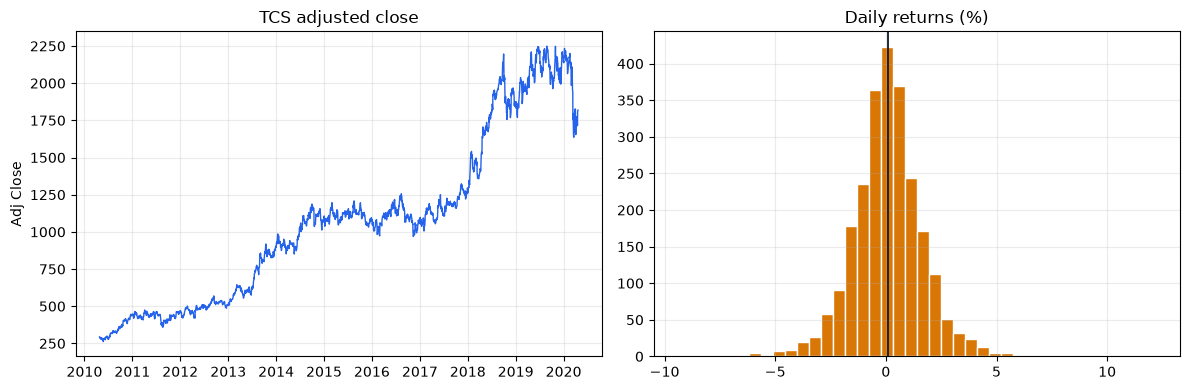

In [16]:
tcs = pd.read_csv(DATA_FILE)
tcs["Date"] = pd.to_datetime(tcs["Date"], dayfirst=True)
tcs = tcs.sort_values("Date").reset_index(drop=True)
tcs["daily_return"] = tcs["Adj Close"].pct_change()
tcs["rolling_20_vol"] = tcs["daily_return"].rolling(20).std() * np.sqrt(252)

summary = pd.DataFrame({
    "metric": ["rows", "start", "end", "mean daily return", "annualized volatility"],
    "value": [
        len(tcs),
        tcs["Date"].min().date(),
        tcs["Date"].max().date(),
        round(tcs["daily_return"].mean(), 6),
        round(tcs["daily_return"].std() * np.sqrt(252), 4),
    ],
})
display(summary)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(tcs["Date"], tcs["Adj Close"], color="#2563eb", linewidth=1)
axes[0].set_title("TCS adjusted close")
axes[0].set_ylabel("Adj Close")
axes[0].grid(True, alpha=0.25)

returns_pct = tcs["daily_return"].dropna() * 100
axes[1].hist(returns_pct, bins=40, color="#d97706", edgecolor="white")
axes[1].axvline(returns_pct.mean(), color="#111827", linewidth=1.3)
axes[1].set_title("Daily returns (%)")
axes[1].grid(True, alpha=0.25)
plt.tight_layout()
plt.show()

## 5. AI, Git, and tool choices

The instructor's guidance was practical: AI is useful for examples and explanations, but it must not turn code into a black box. If an answer uses `rolling`, `shift`, `pct_change`, or `np.where`, verify each function and test the output. Use Git/GitHub for checkpoints, and choose Notebook, JupyterLab, VS Code, Spyder, or PyCharm based on the work style.

In [17]:
tools = pd.read_csv("week6_learning_tools_reference.csv")
display(tools)

prompt_template = """
I am learning Python for quant trading. Explain this code line by line,
list the pandas/numpy functions used, and give one small test case so I can verify it:
<paste code here>
""".strip()
print(prompt_template)

,tool,best_for,watch_out
0,Jupyter Notebook,Linear notebooks and beginner-friendly practice,Execution order can drift from top-to-bottom
1,JupyterLab,Notebook work with a fuller browser-based IDE ...,More panels can distract beginners
2,VS Code,"Projects, Git, scripts, notebooks, and integra...",Needs environment selection discipline
3,PyCharm or Spyder,IDE-style Python work,May feel heavier than needed for early notebooks
4,Git and GitHub,"Version control, rollback, and sharing code","Commit small, meaningful checkpoints"
5,LLM assistant,"Finding examples, explaining unfamiliar functi...","You must verify every API, assumption, and tra..."
6,LeetCode/HackerRank/HackerEarth,Extra practice after basics are comfortable,Do not skip domain notebooks and data exercises


I am learning Python for quant trading. Explain this code line by line,
list the pandas/numpy functions used, and give one small test case so I can verify it:
<paste code here>


## 6. Benchmarking without magic syntax

`%timeit` is the Jupyter shortcut. The standard-library `timeit` module does the same style of repeated measurement in plain Python scripts.

In [18]:
sizes = [10, 20, 1000, 10000]
timing_rows = []
for n in sizes:
    samples = timeit.repeat(lambda n=n: sum(range(n)), repeat=5, number=1000)
    timing_rows.append({"n": n, "best_microseconds_per_call": min(samples) / 1000 * 1_000_000})

timings = pd.DataFrame(timing_rows)
timings["ratio_vs_previous"] = timings["best_microseconds_per_call"].div(timings["best_microseconds_per_call"].shift(1)).round(2)
display(timings)
print("Benchmark complete - compare ratios as input size grows.")

,n,best_microseconds_per_call,ratio_vs_previous
0,10,0.2395,NaN
1,20,0.2976,1.24
2,1000,12.7683,42.90
3,10000,146.5288,11.48


Benchmark complete - compare ratios as input size grows.


## Addendum summary

- `from B import A` is the correct import order; `urllib.request.urlopen` follows that pattern.
- Inspect APIs before guessing: `dir`, `?`, `??`, `inspect.signature`, and docstrings all reduce black-box coding.
- Keep namespaces explicit when names can collide.
- Use local-data plots to verify file parsing and return calculations.
- AI is a helper, not an authority; verify functions, assumptions, and outputs.